PARAMETER FITTING IMPLEMENTATION

# Preliminaries

In [1]:
# Python packages used in this chapter
from collections import namedtuple
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import urllib.request # use this library to download file from GitHub
try:
    import tellurium as te
except:
    !pip install -q tellurium
    import tellurium as te
import seaborn as sns
from scipy.optimize import minimize, differential_evolution
from typing import Optional

# Simple model

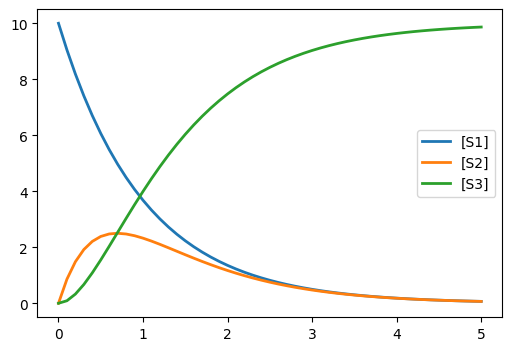

In [2]:
MODEL = """
S1 -> S2; k1*S1
S2 -> S3; k2*S2

S1 = 10
S2 = 0
k1 = 1
k2 = 2
"""
rr = te.loada(MODEL)
rr.simulate()
rr.plot()

# Helpers

In [3]:
def simulate(model: str, observed_df: Optional[str]=None, **kwargs) -> pd.DataFrame:
    """
    Simulates an Antimony model and returns the simulation results as a DataFrame
    with the same shape and timesteps as observed_df.

    Parameters
    ----------
    model: str
        The Antimony model string or a URL
    observed_df: pd.DataFrame
        The experimental data as a pandas DataFrame with 'time' as index.
    kwargs: setting of parameter values

    Returns
    -------
    pd.DataFrame
        The simulation results as a DataFrame with the same shape as observed_df.
    """
    # Get the time points from the observation data
    if "http" in model:
        rr = te.loadSBMLModel(model)
    else:
        rr = te.loada(model)
    for key, value in kwargs.items():
        rr[key] = value
    if observed_df is not None:
        time_points = observed_df.index.values
    else:
        time_points = np.linspace(0, 10, 100)
    # Simulate the model
    sim_data = rr.simulate(float(time_points[0]), float(time_points[-1]),
            len(time_points))
    # Convert simulation results to DataFrame for easier comparison
    sim_columns = [c[1:-1] if c != "time"else c for c in sim_data.colnames]
    sim_df = pd.DataFrame(sim_data, columns=sim_columns)
    sim_df = sim_df.set_index("time")
    return sim_df

# Tests
sim_df = simulate(MODEL)
assert(len(sim_df) > 0)
#
URL = "https://www.ebi.ac.uk/biomodels/services/download/get-files/MODEL8342350003/3/BIOMD0000000145_url.xml"
sim_df = simulate(URL)
assert(len(sim_df) > 0)
print("OK!")

OK!


# Creating synthetic observational data

In [4]:
# Author: Gemini (with some edits)
def simulate_and_add_noise(antimony_model: str, std_dev: float) -> pd.DataFrame:
    """
    Simulates an Antimony model and adds Gaussian noise in log space to the output.

    Args:
        antimony_model (str): The Antimony model string.
        std_dev (float): The standard deviation of the Gaussian noise.

    Returns:
        pandas.DataFrame: A DataFrame containing the simulation results with added noise.
    """
    # Load and simulate the model
    simulation_df = simulate(antimony_model)
    # Add Gaussian noise in log space, avoiding log(0)
    # Add a small epsilon to handle potential zero values before taking log
    epsilon = 1e-9
    log_simulation_df = np.log(simulation_df + epsilon) +  \
                        np.random.normal(0, std_dev, size=simulation_df.shape)
    noisy_df = np.exp(log_simulation_df)
    noisy_df.columns = simulation_df.columns
    noisy_df.index = simulation_df.index
    return noisy_df

# Test the function with a sample model and noise level
noisy_simulation_df = simulate_and_add_noise(MODEL, std_dev=0.1)
assert(len(noisy_simulation_df) > 0)
assert(all([c in noisy_simulation_df.columns for c in ["S1", "S2", "S3"]]))
print("OK!")

OK!


In [5]:
NOISY_SIMULATION_DF = simulate_and_add_noise(MODEL, std_dev=0.1)
NOISY_SIMULATION_DF.head()

,S1,S2,S3
time,,,
0.00000,9.405589,1.039259e-09,9.189873e-10
0.10101,11.464089,7.567845e-01,9.793028e-02
0.20202,7.123263,1.711077e+00,3.634793e-01
0.30303,5.705034,1.582916e+00,6.586471e-01
0.40404,6.617062,2.010102e+00,1.132358e+00


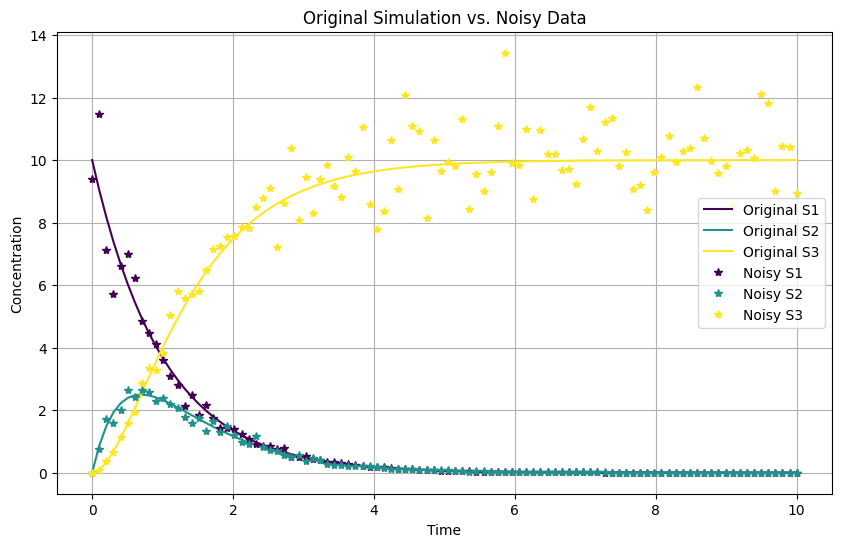

In [6]:
# Simulate the original model without noise
# Author: Gemini
original_df = simulate(MODEL)
colors = cm.viridis(np.linspace(0, 1, len(original_df.columns)))

# Plot the original and noisy data
plt.figure(figsize=(10, 6))

# Plot original concentrations as lines
for idx, col in enumerate(original_df.columns):  # Exclude 'time' column
    plt.plot(original_df.index, original_df[col], label=f'Original {col}',
    c=colors[idx])

# Plot noisy data as asterisks
for idx, col in enumerate(NOISY_SIMULATION_DF.columns):  # Exclude 'time' column
    plt.plot(NOISY_SIMULATION_DF.index, NOISY_SIMULATION_DF[col], '*',
            c=colors[idx], label=f'Noisy {col}')

plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Original Simulation vs. Noisy Data')
plt.legend()
plt.grid(True)
plt.show()

# General Parameter Fitting

## Pseudo code

def estimateParameters(model_ant, parameter_names, observational_data) -> parameter_dct:
    parameter_dct = {}
    
    do until good estimate or exceed runtime limits
        settings = new assignment of values to parameter_names
        simulationResults = run model_ant using settings
        residuals = observedValues - simulationResults
        if the sum of squares of residuals is smaller than previous settings
            parameter_dct is a dictionary of parameter names and the values in settings
        if residuals are very small
            return parameter_dct


Problem: Write code that takes as input
* Model
* Parameter names
* Observational data

And outputs a dictionary of fitted parameters.

## Write a function that evaluates parameters for an arbitrary model

In [7]:
def evaluateParameters(model: str, parameter_dct: dict,
                       observed_df: pd.DataFrame) -> float:
    """
    Runs the model with the given parameters and calculates the sum of squares of residuals.

    Parameters
    ----------
    model: str
        The Antimony model string.
    parameter_dct: dict
        A dictionary of parameter names and their values.
    observed_df: pd.DataFrame
        The experimental data as a pandas DataFrame with 'time' as index.

    Returns
    -------
    float
        The sum of squares of the residuals.
    """
    sim_df = simulate(model, observed_df, **parameter_dct)
    observed_species = observed_df.columns.intersection(sim_df.columns)
    # Calculate the sum of squares of residuals
    # Ensure columns match between simulated and observed data, exclude 'time'
    #import pdb; pdb.set_trace()
    observed_species = observed_df.columns.intersection(sim_df.columns)
    ssq = np.sum((observed_df[observed_species] -  \
            sim_df[observed_species].values)**2, axis=0).sum(axis=0)
    return ssq

# # Example usage (optional, for testing)
# # Let's try with the nominal parameters from the model
nominal_params = {'k1': 1, 'k2': 2}
ssq_nominal = evaluateParameters(MODEL, nominal_params, NOISY_SIMULATION_DF)
print(f"Sum of squares with nominal parameters: {ssq_nominal}")

Sum of squares with nominal parameters: 98.10711542999441


## Write a script for doing the parameter estimation

In [8]:
"""def estimateParameters(model_ant:
        str, starting_parameter_dct: dict,
        observational_data: pd.DataFrame) -> dict:
"""
"""
Estimates parameters for a given Antimony model using a Levenberg-Marquardt algorithm.

Parameters
----------
model_ant: str
    The Antimony model string.
starting_parameter_dct: dict
    A dictionary of starting parameter names and their initial values.
observational_data: pd.DataFrame
    The experimental data as a pandas DataFrame with 'time' as index.

Returns
-------
dict
    A dictionary of parameter names and their estimated values.
"""
_ = """
model_ant = MODEL
starting_parameter_dct = {'k1': 1, 'k2': 1}
observational_data = NOISY_SIMULATION_DF
###########
# Internal function for minimizer
def evaluateEstimates(parameter_arr: np.ndarray) -> float:
    # Construct the dictionary of parameter values
    dct = {}
    for idx, parameter_name in enumerate(starting_parameter_dct.keys()):
        dct[parameter_name] = parameter_arr[idx]
    ssq = evaluateParameters(model_ant, dct, observational_data)
    return ssq

# Do the optimization
# First attempt at parameter estimation for a model
starting_arr = np.array(list(starting_parameter_dct.values()))

# Use differential_evolution directly
res = minimize(
    evaluateEstimates,
    x0=starting_arr # Example bounds, you might need to adjust these
)

# Extract the estimated parameter values from the result object
estimated_parameters = res.x

# Create a dictionary of parameter names and their estimated values
estimated_parameter_dct = {}
for i, param_name in enumerate(starting_parameter_dct.keys()):
    estimated_parameter_dct[param_name] = estimated_parameters[i]
print("Estimated Parameters:")
print(estimated_parameter_dct)
"""

**SUMMARY OF CODE CHANGES**
1. Bug fix. Incorrect structure of observational data: Time was not the index of the DataFrame.
2. Create ``simulate`` to create a dataframe for a simulation (and handle references to models via URL). Makes code more readable and more functional.
3. Better handling of colors in scatter and line plots of results of parameter estimation
1. Used namedtuple to describe a complex set of returned values from ``estimateParameters``.
1. Variables only used within a cell are lower case. Variables that are used between cells are UPPER CASE.

## Make the script into a function

In [9]:
EstimatedParametersResult = namedtuple("EstimatedParameterResult",
        ["parameter_dct", "ssq", "nfev", "success"])
#
def estimateParameters(model_ant:
        str, starting_parameter_dct: dict,
        observed_df: pd.DataFrame,
        **kwargs) -> dict:

    """
    Estimates parameters for a given Antimony model using a Levenberg-Marquardt algorithm.

    Parameters
    ----------
    model_ant: str
        The Antimony model string.
    starting_parameter_dct: dict
        A dictionary of starting parameter names and their initial values.
    observed_df: pd.DataFrame
        The experimental data as a pandas DataFrame with 'time' as index.
    kwargs: options for minimizer
        maxiter: maximum number of iterations

    Returns
    -------
    EstimatedParametersResult
        parameter_dict: dictionary of estimated parameter values
        ssq: sum of squares from the estimation
        nfev: number of function evaluations
        success: boolean indicating if the optimization was successful
    """
    ##
    # Internal function for minimizer
    def evaluateEstimates(parameter_arr: np.ndarray) -> float:
        # Construct the dictionary of parameter values
        dct = {}
        for idx, parameter_name in enumerate(starting_parameter_dct.keys()):
            dct[parameter_name] = parameter_arr[idx]
        ssq = evaluateParameters(model_ant, dct, observed_df)
        return ssq
    ##
    # Do the optimization
    starting_arr = np.array(list(starting_parameter_dct.values()))
    res = minimize(
        evaluateEstimates,
        x0=starting_arr, # Example bounds, you might need to adjust these
        options=kwargs,
        method='Nelder-Mead',
    )
    # Extract the estimated parameter values from the result object
    estimated_parameters = res.x
    # Create a dictionary of parameter names and their estimated values
    estimated_parameter_dct = {}
    for i, param_name in enumerate(starting_parameter_dct.keys()):
        estimated_parameter_dct[param_name] = estimated_parameters[i]
    #
    estimated_parameters_result = EstimatedParametersResult(
            parameter_dct=estimated_parameter_dct,
            ssq=res.fun,
            nfev=res.nfev,
            success=res.success
    )
    return estimated_parameters_result

# Tests
rr = te.loada(MODEL)
estimated_parameters_result = estimateParameters(MODEL,
        starting_parameter_dct={'k1': 1, 'k2': 1},
        observed_df=NOISY_SIMULATION_DF,
        maxiter=100)
parameter_dct = estimated_parameters_result.parameter_dct
assert(np.abs(parameter_dct['k1'] - rr.k1)<0.1)
assert(np.abs(parameter_dct['k2'] - rr.k2)<0.1)
print("OK!")

OK!


In [10]:
parameter_dct

{'k1': np.float64(1.0195022828529845), 'k2': np.float64(2.0593423898320196)}

In [11]:
estimated_parameters_result.ssq

np.float64(97.68406205369084)

In [12]:
estimated_parameters_result.nfev

70

In [13]:
estimated_parameters_result.success

True

## Plot the result

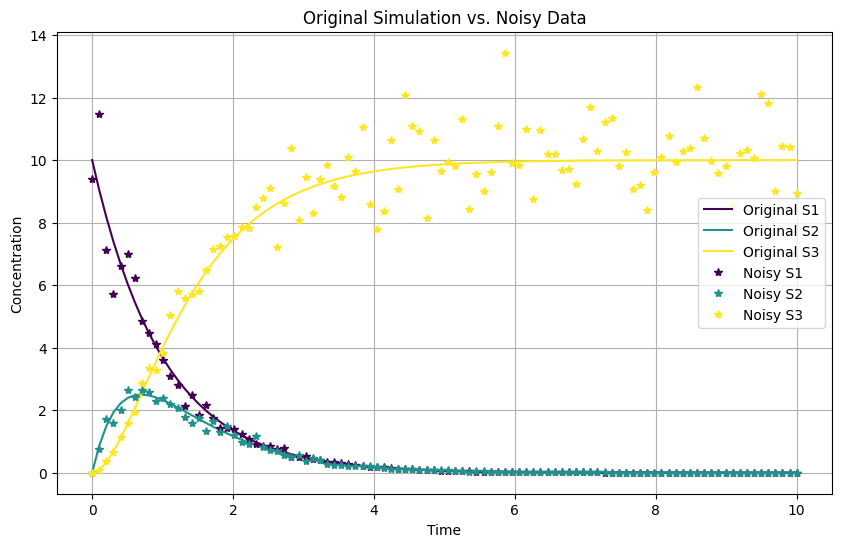

In [14]:
def plotResults(model, estimated_parameter_dct, observed_df):
    # Plot the simulated model with the parameter estimates and
    # the observational data.
    original_df = simulate(model)
    colors = cm.viridis(np.linspace(0, 1, len(original_df.columns)))
    # Plot the original and noisy data
    plt.figure(figsize=(10, 6))
    # Plot original concentrations as lines
    for idx, col in enumerate(original_df.columns):  # Exclude 'time' column
        plt.plot(original_df.index, original_df[col], label=f'Original {col}',
        c=colors[idx])
    # Plot noisy data as asterisks
    for idx, col in enumerate(observed_df.columns):  # Exclude 'time' column
        plt.plot(observed_df.index, observed_df[col], '*',
                c=colors[idx], label=f'Noisy {col}')
    plt.xlabel('Time')
    plt.ylabel('Concentration')
    plt.title('Original Simulation vs. Noisy Data')
    plt.legend()
    plt.grid(True)
    plt.show()

# Tests
plotResults(MODEL, parameter_dct, NOISY_SIMULATION_DF)

# Practice Doing Parameter Fitting

## ATP Oscillations

1. Get the model URL and print the model
1. Create synthetic observational data
1. Create the starting_parameter_dct
1. Estimate parameters
1. Plot estimates with observational data
1. Evaluate the quality of the fit

### Step 1: Get URL and print the model

In [15]:
URL = "https://www.ebi.ac.uk/biomodels/services/download/get-files/MODEL8342350003/3/BIOMD0000000145_url.xml"
rr = te.loadSBMLModel(URL)
print(rr.getAntimony())

// Created by libAntimony v3.0.0
model *BIOMD0000000145()

  // Compartments and Species:
  compartment Cytosol, ER;
  species Galpha_GTP in Cytosol, APLC in Cytosol, IP3 in Cytosol, Ca_ER in ER;
  species Ca_Cyt in Cytosol, $PLC in Cytosol, $DG in Cytosol;

  // Assignment Rules:
  PLC := Cplc_total - APLC;
  DG := IP3;
  Raplc := APLC/(Kp + APLC);
  Rpkc := (DG/(Kd + DG))*Ca_Cyt/(Kr + Ca_Cyt);
  Rgalpha_gtp := Galpha_GTP^n/(Kg^n + Galpha_GTP^n);
  Rdg := DG^m/(Kd^m + DG^m);
  Rip3 := IP3^3/(Ks^3 + IP3^3);
  Rcyt1 := Ca_Cyt/(Kc1 + Ca_Cyt);
  Rcyt2 := Ca_Cyt/(Kc2 + Ca_Cyt);
  Rer := Ca_ER^w/(Ker^w + Ca_ER^w);

  // Reactions:
  R1:  => Galpha_GTP; Cytosol*k0;
  R2:  => Galpha_GTP; Cytosol*k1*Galpha_GTP;
  R3: Galpha_GTP => ; Cytosol*k2*Raplc*Galpha_GTP;
  R4: Galpha_GTP => ; Cytosol*k3*Rpkc*Galpha_GTP;
  R5:  => APLC; Cytosol*k4*Rgalpha_gtp*Rdg*PLC;
  R6: APLC => ; Cytosol*k5*APLC;
  R7:  => IP3; Cytosol*k6*APLC;
  R8: IP3 => ; Cytosol*k7*IP3;
  R9: 0.001 Ca_ER -> 0.01 Ca_Cyt; ER*(k8*R

### Step 2: Create synthetic data

In [16]:
SYNTHETIC_DF = simulate_and_add_noise(URL, std_dev=0.1)
SYNTHETIC_DF.head()

,Galpha_GTP,APLC,IP3,Ca_ER,Ca_Cyt,PLC,DG
time,,,,,,,
0.00000,1.005176,8.164144,0.875305,800.280666,193.496061,1.090775,1.079150
0.10101,0.821987,9.042969,13.879269,1054.071080,224.619994,0.985062,12.191388
0.20202,0.899249,8.878164,21.948725,1075.812333,175.360604,1.421950,22.477691
0.30303,0.888124,8.486850,31.781234,1100.286320,221.902509,1.368009,31.084502
0.40404,0.755538,8.035141,32.348389,1058.152731,215.482797,1.575828,30.598256


### Step 3: Create the starting_parameter_dct

For verifying the credibility of the model parameters, it's reasonable to use starting parameter values that are modest deviations of those in the model.

In [17]:
original_dict= dict(
  k0 = 0.1,
  k1 = 3.4,
  #k2 = 4,
  #k3 = 4.5,
  #k4 = 1.2,
  #k5 = 0.12
)
STARTING_PARAMETER_DCT = {}
for key, value in original_dict.items():
    STARTING_PARAMETER_DCT[key] = value*np.random.uniform(0.8, 1.2)
STARTING_PARAMETER_DCT

{'k0': 0.09231124566129663, 'k1': 3.8679843710019544}

### Step 4: Estimate parameters

In [ ]:
ESTIMATE_PARAMETERS_RESULT = estimateParameters(URL, STARTING_PARAMETER_DCT, SYNTHETIC_DF)

### Step 5: Plot the results

In [ ]:
plotResults(URL, ESTIMATE_PARAMETERS_RESULT.parameter_dct, SYNTHETIC_DF)

### Step 6: Evaluate the quality of the fit

In [ ]:
ESTIMATE_PARAMETERS_RESULT

1. The fit lines for species with larger concentrations seem reasonable.
1. The differences between the true values and the estimates are under 20%.
1. We likely need a second plot to evaluate the fits for species with lower concentrations.
1. The fit lines for smaller species likely require a second plot to evaluate.
1. The time to do the fit is significant for just two parameters.